# Plant Disease V3 — True Inception-ResNet + SE Attention

True Inception-ResNet (Concat→project→Add residual) + SE attention + Focal Loss | 24 classes

> **Run on Kaggle/Colab with GPU.** Runtime → Change runtime type → T4 GPU


In [1]:
!pip install kaggle tensorflow scikit-learn matplotlib seaborn pandas numpy Pillow tqdm psutil -q
print('All packages ready.')


All packages ready.


In [2]:
import os,math,random,json,warnings,zipfile,shutil,time,tracemalloc,psutil
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from collections import defaultdict
from itertools import cycle
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,Conv2D,MaxPooling2D,GlobalAveragePooling2D,BatchNormalization,
    Dense,Dropout,Add,Concatenate,Multiply,Reshape,Layer,
    GlobalMaxPooling2D,SeparableConv2D
)
from tensorflow.keras.callbacks import LearningRateScheduler,EarlyStopping,ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,confusion_matrix,
    accuracy_score,precision_score,recall_score,f1_score,roc_curve,auc)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

gpus = tf.config.list_physical_devices('GPU')
for g in gpus: tf.config.experimental.set_memory_growth(g,True)
print(f'TF {tf.__version__} | GPUs: {len(gpus)}')


2026-04-23 19:01:03.628876: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776970864.041923      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776970864.143005      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776970865.123007      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776970865.123052      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776970865.123055      55 computation_placer.cc:177] computation placer alr

TF 2.19.0 | GPUs: 2


In [3]:
NOTEBOOK_ID  = "V3_InceptionResNet_SE"
SEED=42; IMG_SIZE=(256,256); IMG_SHAPE=(256,256,3)
BATCH_SIZE=64; INITIAL_LR=1e-3; EPOCHS=60; DROPOUT_RATE=0.4
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

TARGET_CLASSES = ['Cotton_Aphids', 'Cotton_Army_worm', 'Cotton_Bacterial_Blight', 'Cotton_Healthy', 'Cotton_Powdery_mildew', 'Cotton_Target_Spot', 'Wheat_Brown_rust', 'Wheat_Healthy', 'Wheat_Yellow_rust', 'Potato_Early_blight', 'Potato_Late_blight', 'Potato_Healthy', 'Bell_Pepper_Bacterial_spot', 'Bell_Pepper_Healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites', 'Tomato_Target_spot', 'Tomato_Yellowleaf_curl_virus', 'Tomato_Mosaic_virus', 'Tomato_Healthy']
NUM_CLASSES    = len(TARGET_CLASSES)
CLASS_TO_IDX   = {c:i for i,c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS   = {i:c for i,c in enumerate(TARGET_CLASSES)}
TARGET_COUNTS  = {'Cotton_Aphids': 800, 'Cotton_Army_worm': 800, 'Cotton_Bacterial_Blight': 800, 'Cotton_Healthy': 800, 'Cotton_Powdery_mildew': 800, 'Cotton_Target_Spot': 788, 'Wheat_Brown_rust': 902, 'Wheat_Healthy': 1116, 'Wheat_Yellow_rust': 924, 'Potato_Early_blight': 1000, 'Potato_Late_blight': 1000, 'Potato_Healthy': 152, 'Bell_Pepper_Bacterial_spot': 997, 'Bell_Pepper_Healthy': 1478, 'Tomato_Bacterial_spot': 2127, 'Tomato_Early_blight': 1000, 'Tomato_Late_blight': 1909, 'Tomato_Leaf_mold': 952, 'Tomato_Septoria_leaf_spot': 1771, 'Tomato_Spider_mites': 1676, 'Tomato_Target_spot': 1404, 'Tomato_Yellowleaf_curl_virus': 3209, 'Tomato_Mosaic_virus': 373, 'Tomato_Healthy': 1591}
KAGGLE_DATASETS= [
    ('mohitsingh1804/plantvillage',    'plantvillage'),
    ('dhamur/cotton-plant-disease',    'cotton-plant-disease'),
    ('sinadunk23/behzad-safari-jalal', 'behzad-safari-jalal'),
]
VALID_EXTS = {'.jpg','.jpeg','.png','.bmp','.tif','.tiff'}

BASE_DIR    = os.path.join(os.path.expanduser('~'),'plant_project', NOTEBOOK_ID)
RAW_DIR     = os.path.join(os.path.expanduser('~'),'plant_project','raw')
UNIFIED_DIR = os.path.join(BASE_DIR,'unified')
CKPT_DIR    = os.path.join(BASE_DIR,'checkpoints')
LOG_DIR     = os.path.join(BASE_DIR,'logs')
for d in [BASE_DIR,RAW_DIR,UNIFIED_DIR,CKPT_DIR,LOG_DIR]: os.makedirs(d,exist_ok=True)

def get_images(folder):
    if not os.path.isdir(folder): return []
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in VALID_EXTS]

print(f'Notebook  : {NOTEBOOK_ID}')
print(f'Classes   : {NUM_CLASSES} | Base: {BASE_DIR}')


Notebook  : V3_InceptionResNet_SE
Classes   : 24 | Base: /root/plant_project/V3_InceptionResNet_SE


In [4]:
KAGGLE_USERNAME = "jyotiradityachillal"
KAGGLE_KEY      = "KGAT_bba51b5487bd42a6dc26ac9524d520f9"
import json as _j
kd = os.path.expanduser("~/.kaggle"); os.makedirs(kd,exist_ok=True)
with open(os.path.join(kd,"kaggle.json"),"w") as f:
    _j.dump({"username":KAGGLE_USERNAME,"key":KAGGLE_KEY},f)
os.chmod(os.path.join(kd,"kaggle.json"),0o600)
os.environ["KAGGLE_USERNAME"]=KAGGLE_USERNAME
os.environ["KAGGLE_KEY"]=KAGGLE_KEY
print("Kaggle credentials set.")


Kaggle credentials set.


In [5]:
orig=os.getcwd(); os.chdir(RAW_DIR)
for ds_slug,folder_name in KAGGLE_DATASETS:
    tf_dir=os.path.join(RAW_DIR,folder_name)
    zf=os.path.join(RAW_DIR,folder_name+'.zip')
    if os.path.isdir(tf_dir) and os.listdir(tf_dir):
        print(f'  Ready: {folder_name}/'); continue
    if not os.path.isfile(zf):
        os.system(f'kaggle datasets download -d {ds_slug} --quiet')
    import zipfile as _zf
    with _zf.ZipFile(zf,'r') as z: z.extractall(tf_dir)
    print(f'  Extracted: {folder_name}')
os.chdir(orig); print('All datasets ready.')


Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
  Extracted: plantvillage
Dataset URL: https://www.kaggle.com/datasets/dhamur/cotton-plant-disease
License(s): ODbL-1.0
  Extracted: cotton-plant-disease
Dataset URL: https://www.kaggle.com/datasets/sinadunk23/behzad-safari-jalal
License(s): unknown
  Extracted: behzad-safari-jalal
All datasets ready.


In [6]:
# ── Folder name → class resolver (covers all known naming variants) ────────
FOLDER_MAP = {
    'aphids':'Cotton_Aphids','aphid':'Cotton_Aphids',
    'army worm':'Cotton_Army_worm','army_worm':'Cotton_Army_worm','armyworm':'Cotton_Army_worm',
    'bacterial blight':'Cotton_Bacterial_Blight','bacterial_blight':'Cotton_Bacterial_Blight',
    'powdery mildew':'Cotton_Powdery_mildew','powdery_mildew':'Cotton_Powdery_mildew',
    'powderymildew':'Cotton_Powdery_mildew',
    'target spot':'Cotton_Target_Spot','target_spot':'Cotton_Target_Spot',
    'pepper,_bell___bacterial_spot':'Bell_Pepper_Bacterial_spot',
    'pepper___bacterial_spot':'Bell_Pepper_Bacterial_spot',
    'bell_pepper___bacterial_spot':'Bell_Pepper_Bacterial_spot',
    'pepper,_bell___healthy':'Bell_Pepper_Healthy',
    'pepper___healthy':'Bell_Pepper_Healthy',
    'bell_pepper___healthy':'Bell_Pepper_Healthy',
    'potato___early_blight':'Potato_Early_blight',
    'potato___late_blight':'Potato_Late_blight',
    'potato___healthy':'Potato_Healthy',
    'tomato___bacterial_spot':'Tomato_Bacterial_spot',
    'tomato___early_blight':'Tomato_Early_blight',
    'tomato___late_blight':'Tomato_Late_blight',
    'tomato___leaf_mold':'Tomato_Leaf_mold',
    'tomato___septoria_leaf_spot':'Tomato_Septoria_leaf_spot',
    'tomato___spider_mites two-spotted_spider_mite':'Tomato_Spider_mites',
    'tomato___spider_mites_two-spotted_spider_mite':'Tomato_Spider_mites',
    'tomato___spider_mites':'Tomato_Spider_mites',
    'tomato___target_spot':'Tomato_Target_spot',
    'tomato___tomato_yellow_leaf_curl_virus':'Tomato_Yellowleaf_curl_virus',
    'tomato___tomato_mosaic_virus':'Tomato_Mosaic_virus',
    'tomato___healthy':'Tomato_Healthy',
    'brown rust':'Wheat_Brown_rust','brown_rust':'Wheat_Brown_rust','brownrust':'Wheat_Brown_rust',
    'yellow rust':'Wheat_Yellow_rust','yellow_rust':'Wheat_Yellow_rust','yellowrust':'Wheat_Yellow_rust',
    # wheat healthy aliases (covers behzad dataset folder names)
    'wheat_healthy':'Wheat_Healthy','wheat healthy':'Wheat_Healthy',
    'wheat___healthy':'Wheat_Healthy','healthywheat':'Wheat_Healthy',
}
HEALTHY_CTX = {
    'cotton':'Cotton_Healthy','wheat':'Wheat_Healthy','potato':'Potato_Healthy',
    'behzad':'Wheat_Healthy','jalal':'Wheat_Healthy',
}

def resolve_class(p):
    name = os.path.basename(p).lower().strip()
    if name in FOLDER_MAP: return FOLDER_MAP[name]
    if name in ('healthy','normal','disease free'):
        fl = p.lower()
        for k,v in HEALTHY_CTX.items():
            if k in fl: return v
    return None

# Scan all dataset roots
class_files = defaultdict(list)
for _,folder in KAGGLE_DATASETS:
    ds_root = os.path.join(RAW_DIR,folder)
    if not os.path.isdir(ds_root): continue
    for dp,_,fnames in os.walk(ds_root):
        imgs=[f for f in fnames if os.path.splitext(f)[1].lower() in VALID_EXTS]
        if not imgs: continue
        cls = resolve_class(dp)
        if cls and cls in TARGET_CLASSES:
            class_files[cls].extend([os.path.join(dp,f) for f in imgs])

print('Scan done:')
for cls in TARGET_CLASSES:
    n=len(class_files[cls])
    flag=' ← MISSING' if n==0 else ''
    print(f'  {cls:<40} {n:>5}{flag}')


Scan done:
  Cotton_Aphids                             4320
  Cotton_Army_worm                          4320
  Cotton_Bacterial_Blight                   4320
  Cotton_Healthy                            4320
  Cotton_Powdery_mildew                     4320
  Cotton_Target_Spot                        4271
  Wheat_Brown_rust                          1128
  Wheat_Healthy                             1395
  Wheat_Yellow_rust                         1156
  Potato_Early_blight                       1000
  Potato_Late_blight                        1000
  Potato_Healthy                             152
  Bell_Pepper_Bacterial_spot                 997
  Bell_Pepper_Healthy                       1478
  Tomato_Bacterial_spot                     2127
  Tomato_Early_blight                       1000
  Tomato_Late_blight                        1909
  Tomato_Leaf_mold                           952
  Tomato_Septoria_leaf_spot                 1771
  Tomato_Spider_mites                       1676
  Tomato_

In [7]:
# ── Build unified dataset (one folder per class, capped at TARGET_COUNTS) ──
random.seed(SEED); actual_counts={}
for cls in TARGET_CLASSES:
    cls_dir = os.path.join(UNIFIED_DIR,cls); os.makedirs(cls_dir,exist_ok=True)
    ex = get_images(cls_dir)
    if ex: actual_counts[cls]=len(ex); continue
    srcs = class_files[cls][:]
    random.shuffle(srcs); srcs=srcs[:TARGET_COUNTS.get(cls,999999)]
    for i,src in enumerate(srcs):
        ext=os.path.splitext(src)[1].lower() or '.jpg'
        dst=os.path.join(cls_dir,f'{i:05d}{ext}')
        if not os.path.exists(dst): shutil.copy2(src,dst)
    actual_counts[cls]=len(srcs)
total=sum(actual_counts.values())
print(f'Unified: {total:,} images | {NUM_CLASSES} classes')

# Collect all paths + labels
all_paths,all_labels=[],[]
for cls in TARGET_CLASSES:
    imgs=get_images(os.path.join(UNIFIED_DIR,cls))
    all_paths.extend(imgs); all_labels.extend([CLASS_TO_IDX[cls]]*len(imgs))
all_paths=np.array(all_paths); all_labels=np.array(all_labels,dtype=np.int32)

# ── Class weights — safe, handles missing classes (e.g. Wheat_Healthy=0) ──
present = np.unique(all_labels)
missing = [i for i in range(NUM_CLASSES) if i not in present]
if missing:
    print(f'WARNING: {len(missing)} classes have 0 images: {[TARGET_CLASSES[i] for i in missing]}')
cw = compute_class_weight('balanced',classes=present,y=all_labels)
class_weights = {i:1.0 for i in range(NUM_CLASSES)}   # default=1.0 for missing
for idx,w in zip(present,cw): class_weights[idx]=w

print('\nClass weights (boosted classes only):')
for i,cls in enumerate(TARGET_CLASSES):
    w=class_weights[i]
    if w>1.5 or i in missing:
        tag=' ← MISSING (weight=1.0 placeholder)' if i in missing else f'  weight={w:.2f}'
        print(f'  {cls:<40}{tag}')


Unified: 28,369 images | 24 classes

Class weights (boosted classes only):
  Cotton_Target_Spot                        weight=1.50
  Potato_Healthy                            weight=7.78
  Tomato_Mosaic_virus                       weight=3.17


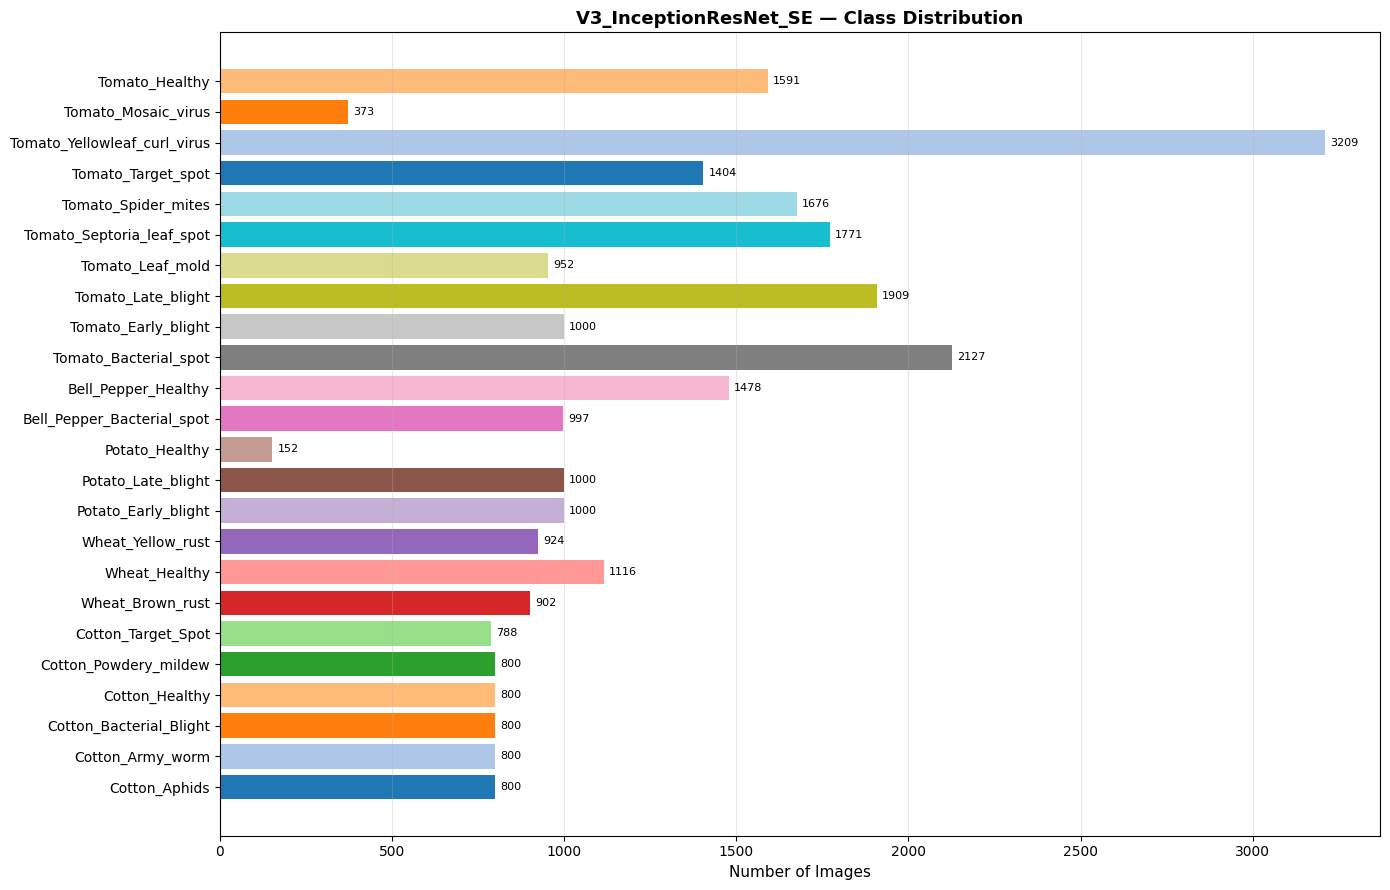

Total images: 28,369


In [8]:
# EDA — class distribution
counts=[actual_counts.get(c,0) for c in TARGET_CLASSES]
fig,ax=plt.subplots(figsize=(14,9))
colors=plt.cm.tab20.colors
bars=ax.barh(TARGET_CLASSES,counts,color=[colors[i%20] for i in range(NUM_CLASSES)])
ax.set_xlabel('Number of Images',fontsize=11)
ax.set_title(f'{NOTEBOOK_ID} — Class Distribution',fontweight='bold',fontsize=13)
ax.grid(True,axis='x',alpha=0.3)
for bar,v in zip(bars,counts):
    ax.text(bar.get_width()+15,bar.get_y()+bar.get_height()/2,str(v),va='center',fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'eda_distribution.png'),dpi=120,bbox_inches='tight')
plt.show()
print(f'Total images: {sum(counts):,}')


In [9]:
# Train / Val / Test split — stratified 70/15/15
X_tr,X_tmp,y_tr,y_tmp=train_test_split(
    all_paths,all_labels,test_size=0.30,random_state=SEED,stratify=all_labels)
X_val,X_te,y_val,y_te=train_test_split(
    X_tmp,y_tmp,test_size=0.50,random_state=SEED,stratify=y_tmp)
print(f'Train {len(X_tr):,}  |  Val {len(X_val):,}  |  Test {len(X_te):,}')

import tensorflow as tf
AUTOTUNE=tf.data.AUTOTUNE

def load_img(path,label):
    raw=tf.io.read_file(path)
    img=tf.image.decode_image(raw,channels=3,expand_animations=False)
    img=tf.image.resize(img,IMG_SIZE)
    return tf.cast(img,tf.float32)/255.0, label

def augment(img,label):
    img=tf.image.random_flip_left_right(img)
    img=tf.image.random_flip_up_down(img)
    img=tf.image.random_brightness(img,0.2)
    img=tf.image.random_contrast(img,0.8,1.2)
    img=tf.image.random_saturation(img,0.8,1.2)
    img=tf.image.random_hue(img,0.08)
    img=tf.image.random_jpeg_quality(img,70,100)
    return tf.clip_by_value(img,0.0,1.0),label

def make_ds(paths,labels,training=False):
    ds=tf.data.Dataset.from_tensor_slices((paths,labels))
    if training: ds=ds.shuffle(min(len(paths),10000),seed=SEED)
    ds=ds.map(load_img,num_parallel_calls=AUTOTUNE)
    if training: ds=ds.map(augment,num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds=make_ds(X_tr,y_tr,training=True)
val_ds=make_ds(X_val,y_val)
test_ds=make_ds(X_te,y_te)
print('tf.data pipelines ready.')


Train 19,858  |  Val 4,255  |  Test 4,256


I0000 00:00:1776970997.316042      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776970997.322324      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


tf.data pipelines ready.


In [10]:
class CosineWarmupScheduler(LearningRateScheduler):
    """Cosine annealing with linear warmup (5 epochs default)."""
    def __init__(self,initial_lr,total_epochs,warmup_epochs=5):
        self.initial_lr=initial_lr; self.total_epochs=total_epochs; self.warmup=warmup_epochs
        super().__init__(self._sched,verbose=0)
    def _sched(self,epoch,lr):
        if epoch<self.warmup: return self.initial_lr*(epoch+1)/self.warmup
        t=epoch-self.warmup; T=self.total_epochs-self.warmup
        return 0.5*self.initial_lr*(1+math.cos(math.pi*t/T))
    def get_config(self):
        cfg=super().get_config()
        cfg.update({'initial_lr':self.initial_lr,'total_epochs':self.total_epochs,'warmup_epochs':self.warmup})
        return cfg
print('CosineWarmupScheduler ready.')


CosineWarmupScheduler ready.


## Architecture V3 — True Inception-ResNet + SE Attention

**Key difference from V1 & original:**
- Branches → Concat → 1×1 projection → Add(residual): true Szegedy 2017 design
- SE block after every Inception-ResNet block
- Larger filter progression: 64→128→256→512 for richer representations
- Stem: Conv7×7 + Conv3×3 (like original InceptionResNet)
- Focal loss + class weights for Cotton/Wheat imbalance


In [11]:
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self,gamma=2.0,alpha=0.25,**kwargs):
        super().__init__(**kwargs); self.gamma=gamma; self.alpha=alpha
    def call(self,y_true,y_pred):
        y_true=tf.cast(tf.reshape(y_true,(-1,)),tf.int32)
        y_pred=tf.clip_by_value(y_pred,1e-7,1.0-1e-7)
        pt=tf.reduce_sum(y_pred*tf.one_hot(y_true,tf.shape(y_pred)[1]),axis=-1)
        return tf.reduce_mean(-self.alpha*tf.pow(1.0-pt,self.gamma)*tf.math.log(pt))
    def get_config(self):
        cfg=super().get_config(); cfg.update({'gamma':self.gamma,'alpha':self.alpha}); return cfg

class InceptionResNetBlock(Layer):
    """
    True Inception-ResNet block (Szegedy 2017):
      branches → Concat → 1×1 projection → Add(shortcut) → BN → ReLU
    All three filter sizes (3×3, 5×5, 7×7) contribute via Concat,
    then projected back to num_filters via 1×1, then residual-added.
    """
    def __init__(self,num_filters,activation='relu',padding='same',**kwargs):
        super().__init__(**kwargs)
        self.num_filters=num_filters; self.activation=activation; self.padding=padding
        f=max(num_filters//3,8)
        self.c3=Conv2D(f,(3,3),activation=activation,padding=padding)
        self.c5=Conv2D(f,(5,5),activation=activation,padding=padding)
        self.c7=Conv2D(f,(7,7),activation=activation,padding=padding)
        self.proj=Conv2D(num_filters,(1,1),activation=None,padding='same')
        self.match=Conv2D(num_filters,(1,1),activation=None,padding='same')
        self.bn=BatchNormalization()
    def call(self,x,training=False):
        b3=self.c3(x); b5=self.c5(x); b7=self.c7(x)
        merged=Concatenate(axis=-1)([b3,b5,b7])
        projected=self.proj(merged)
        shortcut=self.match(x)
        out=self.bn(Add()([projected,shortcut]),training=training)
        return tf.nn.relu(out)
    def get_config(self):
        cfg=super().get_config()
        cfg.update({'num_filters':self.num_filters,'activation':self.activation,'padding':self.padding})
        return cfg

class SEBlock(Layer):
    """Squeeze-Excitation channel attention."""
    def __init__(self,ratio=8,**kwargs):
        super().__init__(**kwargs); self.ratio=ratio
        self.fc1=None; self.fc2=None
    def build(self,input_shape):
        ch=input_shape[-1]
        self.gap=GlobalAveragePooling2D()
        self.fc1=Dense(max(ch//self.ratio,1),activation='relu')
        self.fc2=Dense(ch,activation='sigmoid')
        self.rs=Reshape((1,1,ch))
        self.mul=Multiply()
        super().build(input_shape)
    def call(self,x,training=False):
        sq=self.gap(x); sq=self.fc1(sq); sq=self.fc2(sq); sq=self.rs(sq)
        return self.mul([x,sq])
    def get_config(self):
        cfg=super().get_config(); cfg.update({'ratio':self.ratio}); return cfg

print('V3 layers: InceptionResNetBlock + SE attention + FocalLoss')


V3 layers: InceptionResNetBlock + SE attention + FocalLoss


In [12]:
def build_model():
    inp=Input(shape=IMG_SHAPE)
    # Stem (like original Inception-ResNet)
    x=Conv2D(32,(3,3),strides=2,activation='relu',padding='same')(inp)  # 128×128×32
    x=Conv2D(32,(3,3),activation='relu',padding='same')(x)
    x=BatchNormalization()(x)
    x=MaxPooling2D((2,2))(x)                                            # 64×64×32

    # Inception-ResNet + SE blocks
    x=InceptionResNetBlock(64,name='irb_1')(x)
    x=SEBlock(ratio=8,name='se_1')(x)
    x=MaxPooling2D((2,2))(x)                                            # 32×32×64

    x=InceptionResNetBlock(128,name='irb_2')(x)
    x=SEBlock(ratio=8,name='se_2')(x)
    x=MaxPooling2D((2,2))(x)                                            # 16×16×128

    x=InceptionResNetBlock(256,name='irb_3')(x)
    x=SEBlock(ratio=16,name='se_3')(x)                                  # 16×16×256

    x=GlobalAveragePooling2D()(x)
    x=Dense(512,activation='relu')(x); x=Dropout(0.4)(x)
    x=Dense(256,activation='relu')(x); x=Dropout(0.3)(x)
    out=Dense(NUM_CLASSES,activation='softmax')(x)
    return Model(inp,out,name='V3_InceptionResNet_SE')

model=build_model(); model.summary()
print(f'Params: {model.count_params():,}')
print('Key: Concat branches → 1×1 projection → Add(residual) — true Inception-ResNet')


Model: "V3_InceptionResNet_SE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb_1 (InceptionResNetBlock)    │ (None, 64, 64, 64)     │        62,303 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ se_1 (SEBlock)                  │ (None, 64, 64, 64)     │         1,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb_2 (InceptionResNetBlock)    │ (None, 32, 32, 128)    │       248,318 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ se_2 (SEBlock)                  │ (None, 32, 32, 128)    │         4,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb_3 (InceptionResNetBlock)    │ (None, 16, 16, 256)    │     1,002,879 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ se_3 (SEBlock)                  │ (None, 16, 16, 256)    │         8,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,606,652 (6.13 MB)

 Trainable params: 1,605,692 (6.13 MB)

 Non-trainable params: 960 (3.75 KB)

Params: 1,606,652
Key: Concat branches → 1×1 projection → Add(residual) — true Inception-ResNet


In [13]:
ckpt_path=os.path.join(CKPT_DIR,'best.weights.h5')
model.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss=SparseFocalLoss(gamma=2.0,alpha=0.25),
    metrics=['accuracy'])
callbacks=[
    CosineWarmupScheduler(INITIAL_LR,EPOCHS,warmup_epochs=5),
    ModelCheckpoint(ckpt_path,monitor='val_accuracy',save_best_only=True,
                    save_weights_only=True,verbose=0),
    EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True,verbose=1),
]
tracemalloc.start(); t0=time.time()
history=model.fit(train_ds,epochs=EPOCHS,validation_data=val_ds,
                  class_weight=class_weights,callbacks=callbacks,verbose=1)
train_time=time.time()-t0
_,peak=tracemalloc.get_traced_memory(); tracemalloc.stop()
ram_used_mb=psutil.Process().memory_info().rss/1e6
print(f'Train time: {train_time/60:.1f} min | RAM: {ram_used_mb:.0f} MB')


Epoch 1/60


I0000 00:00:1776971024.502752     143 service.cc:152] XLA service 0x7d723022f550 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776971024.502798     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776971024.502803     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776971026.901119     143 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-23 19:03:54.649375: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 19:03:54.793459: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 19:03:55.401236: E external/local_xl

310/311 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.2626 - loss: 0.5296

2026-04-23 19:05:03.030292: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 19:05:03.169641: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 19:05:03.508436: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 19:05:03.647700: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 19:05:04.008271: E external/local_xla/xla/stream_

311/311 ━━━━━━━━━━━━━━━━━━━━ 124s 243ms/step - accuracy: 0.2633 - loss: 0.5289 - val_accuracy: 0.1149 - val_loss: 1.2964 - learning_rate: 2.0000e-04
Epoch 2/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 53s 171ms/step - accuracy: 0.4906 - loss: 0.2834 - val_accuracy: 0.4181 - val_loss: 0.3571 - learning_rate: 4.0000e-04
Epoch 3/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 53s 170ms/step - accuracy: 0.5792 - loss: 0.2058 - val_accuracy: 0.5880 - val_loss: 0.1941 - learning_rate: 6.0000e-04
Epoch 4/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 52s 168ms/step - accuracy: 0.6151 - loss: 0.1717 - val_accuracy: 0.2378 - val_loss: 0.6797 - learning_rate: 8.0000e-04
Epoch 5/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 52s 167ms/step - accuracy: 0.6560 - loss: 0.1518 - val_accuracy: 0.5807 - val_loss: 0.2176 - learning_rate: 0.0010
Epoch 6/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 75s 240ms/step - accuracy: 0.7018 - loss: 0.1230 - val_accuracy: 0.7438 - val_loss: 0.1001 - learning_rate: 0.0010
Epoch 7/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 53s 171ms/step - accurac

In [14]:
# ── Predict on test set ───────────────────────────────────────────────────
ckpt_path=os.path.join(CKPT_DIR,'best.weights.h5')
if os.path.exists(ckpt_path): model.load_weights(ckpt_path)

y_prob=model.predict(test_ds,verbose=1)
y_pred=np.argmax(y_prob,axis=1)
y_true=np.concatenate([y for _,y in test_ds])[:len(y_pred)]

acc  = accuracy_score(y_true,y_pred)
prec = precision_score(y_true,y_pred,average='weighted',zero_division=0)
rec  = recall_score(y_true,y_pred,average='weighted',zero_division=0)
f1   = f1_score(y_true,y_pred,average='weighted',zero_division=0)

report_dict=classification_report(
    y_true,y_pred,labels=list(range(NUM_CLASSES)),
    target_names=TARGET_CLASSES,output_dict=True,zero_division=0)
sensitivity={cls:report_dict[cls]['recall'] for cls in TARGET_CLASSES}
spec_list=[]
for i in range(NUM_CLASSES):
    tp=np.sum((y_true==i)&(y_pred==i)); fp=np.sum((y_true!=i)&(y_pred==i))
    tn=np.sum((y_true!=i)&(y_pred!=i))
    spec_list.append(tn/(tn+fp) if (tn+fp)>0 else 0)
mean_spec=np.mean(spec_list)

print('='*56); print(f'  RESULTS — {NOTEBOOK_ID}'); print('='*56)
print(f'  Accuracy    : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision   : {prec:.4f}')
print(f'  Recall      : {rec:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  Specificity : {mean_spec:.4f}')
print(f'  Params      : {model.count_params():,}')
print(f'  Train time  : {train_time/60:.1f} min')
print(f'  RAM (MB)    : {ram_used_mb:.1f}')
print('='*56)
print('  vs NB4 Standard Inception : 95.33%  (270K params)')
print('  vs NB5 ResNet-style       : 96.04%  (741K params)')
print('='*56)


67/67 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step
  RESULTS — V3_InceptionResNet_SE
  Accuracy    : 0.9673  (96.73%)
  Precision   : 0.9676
  Recall      : 0.9673
  F1-Score    : 0.9674
  Specificity : 0.9986
  Params      : 1,606,652
  Train time  : 59.4 min
  RAM (MB)    : 4755.3
  vs NB4 Standard Inception : 95.33%  (270K params)
  vs NB5 ResNet-style       : 96.04%  (741K params)


In [15]:
# ── Save all metrics to CSV ────────────────────────────────────────────────
hist=history.history; hist_df=pd.DataFrame(hist)
hist_df['epoch']=range(1,len(hist_df)+1)
hist_df['notebook']=NOTEBOOK_ID; hist_df['train_time_sec']=train_time
hist_df['total_params']=model.count_params(); hist_df['ram_mb']=ram_used_mb
hist_df.to_csv(os.path.join(LOG_DIR,'training_history.csv'),index=False)

metrics_df=pd.DataFrame([{
    'notebook':NOTEBOOK_ID,'accuracy':acc,'precision':prec,'recall':rec,'f1':f1,
    'specificity':mean_spec,'params':model.count_params(),
    'train_time_min':train_time/60,'ram_mb':ram_used_mb,
    'num_classes':NUM_CLASSES,'best_val_acc':max(hist['val_accuracy'])
}])
metrics_df.to_csv(os.path.join(LOG_DIR,'metrics_summary.csv'),index=False)

per_class_df=pd.DataFrame([{
    'class':cls,'sensitivity':sensitivity[cls],
    'precision':report_dict[cls]['precision'],
    'f1':report_dict[cls]['f1-score'],'specificity':spec_list[i]
} for i,cls in enumerate(TARGET_CLASSES)])
per_class_df.to_csv(os.path.join(LOG_DIR,'per_class_metrics.csv'),index=False)
print(f'CSVs saved to {LOG_DIR}')
print(classification_report(y_true,y_pred,target_names=TARGET_CLASSES,digits=4,zero_division=0))


CSVs saved to /root/plant_project/V3_InceptionResNet_SE/logs
                              precision    recall  f1-score   support

               Cotton_Aphids     0.8333    0.8333    0.8333       120
            Cotton_Army_worm     0.9407    0.9250    0.9328       120
     Cotton_Bacterial_Blight     0.8306    0.8583    0.8443       120
              Cotton_Healthy     0.9459    0.8750    0.9091       120
       Cotton_Powdery_mildew     0.8455    0.8667    0.8560       120
          Cotton_Target_Spot     0.7833    0.7966    0.7899       118
            Wheat_Brown_rust     0.9624    0.9481    0.9552       135
               Wheat_Healthy     0.9940    1.0000    0.9970       167
           Wheat_Yellow_rust     0.9645    0.9855    0.9749       138
         Potato_Early_blight     0.9804    1.0000    0.9901       150
          Potato_Late_blight     1.0000    0.9933    0.9967       150
              Potato_Healthy     1.0000    1.0000    1.0000        23
  Bell_Pepper_Bacterial_spot

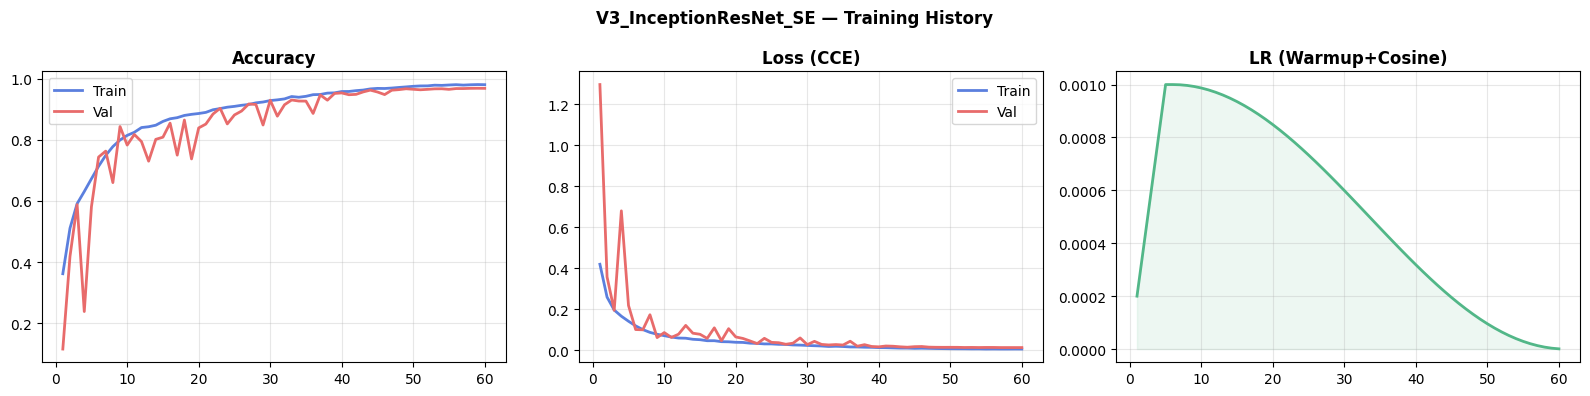

In [16]:
# ── Training curves ────────────────────────────────────────────────────────
n_ep=range(1,len(hist['loss'])+1)
fig,axes=plt.subplots(1,3,figsize=(16,4))
axes[0].plot(n_ep,hist['accuracy'],label='Train',color='#5B7FDE',lw=2)
axes[0].plot(n_ep,hist['val_accuracy'],label='Val',color='#E86B6B',lw=2)
axes[0].set_title('Accuracy',fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(n_ep,hist['loss'],label='Train',color='#5B7FDE',lw=2)
axes[1].plot(n_ep,hist['val_loss'],label='Val',color='#E86B6B',lw=2)
axes[1].set_title('Loss (CCE)',fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)
lrs=[CosineWarmupScheduler(INITIAL_LR,EPOCHS)._sched(e,0) for e in range(len(hist['loss']))]
axes[2].plot(n_ep,lrs,color='#52B788',lw=2)
axes[2].fill_between(n_ep,lrs,alpha=0.1,color='#52B788')
axes[2].set_title('LR (Warmup+Cosine)',fontweight='bold'); axes[2].grid(alpha=0.3)
fig.suptitle(f'{NOTEBOOK_ID} — Training History',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'training_curves.png'),dpi=120,bbox_inches='tight')
plt.show()


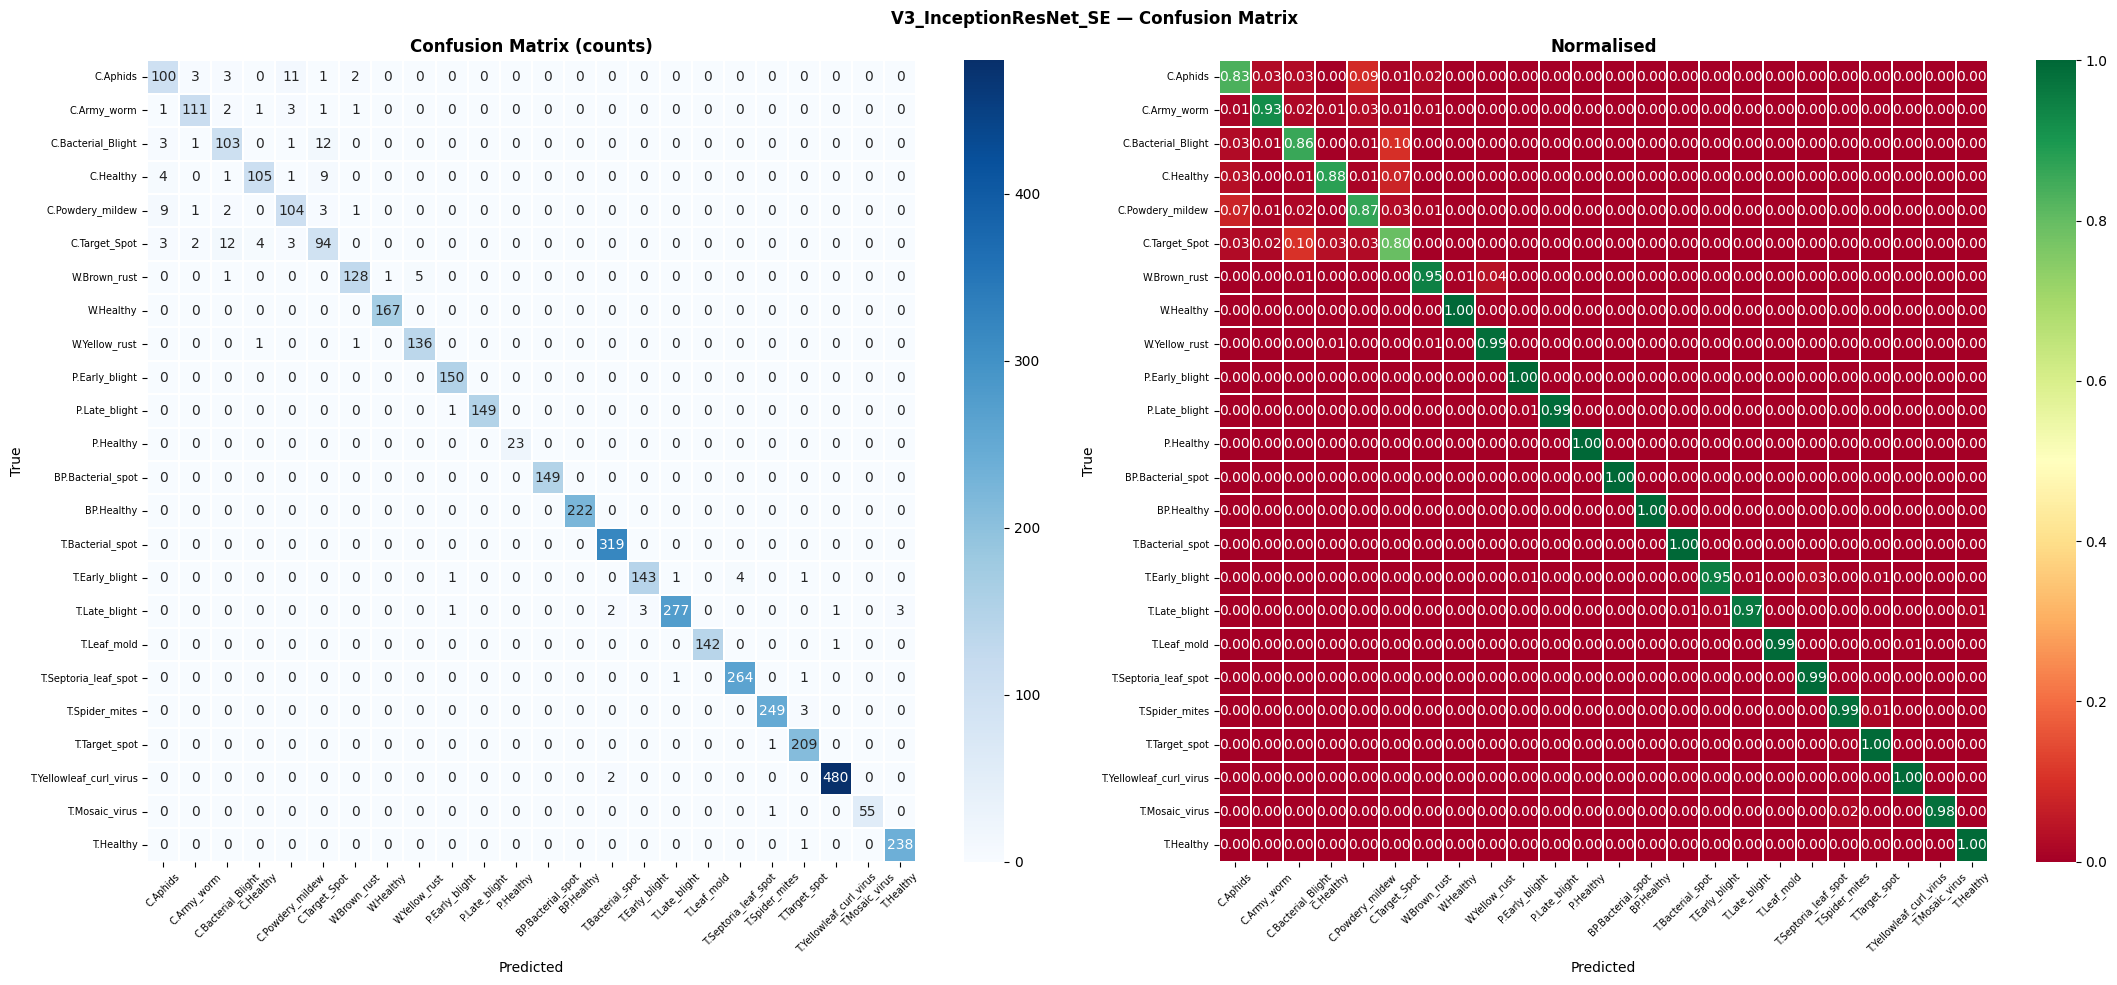

In [17]:
# ── Confusion matrix ──────────────────────────────────────────────────────
cm=confusion_matrix(y_true,y_pred)
cm_norm=cm.astype(float)/np.maximum(cm.sum(axis=1,keepdims=True),1)
short=[c.replace('Cotton_','C.').replace('Wheat_','W.').replace('Potato_','P.')
        .replace('Bell_Pepper_','BP.').replace('Tomato_','T.') for c in TARGET_CLASSES]
fig,axes=plt.subplots(1,2,figsize=(22,10))
for ax,data,fmt,cmap,title in [
    (axes[0],cm,'d','Blues','Confusion Matrix (counts)'),
    (axes[1],cm_norm,'.2f','RdYlGn','Normalised')]:
    sns.heatmap(data,ax=ax,cmap=cmap,fmt=fmt,annot=True,
                xticklabels=short,yticklabels=short,
                linewidths=0.3,linecolor='white',
                **({'vmin':0,'vmax':1} if fmt=='.2f' else {}))
    ax.set_title(title,fontweight='bold'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x',rotation=45,labelsize=7)
    ax.tick_params(axis='y',rotation=0,labelsize=7)
plt.suptitle(f'{NOTEBOOK_ID} — Confusion Matrix',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'confusion_matrix.png'),dpi=120,bbox_inches='tight')
plt.show()


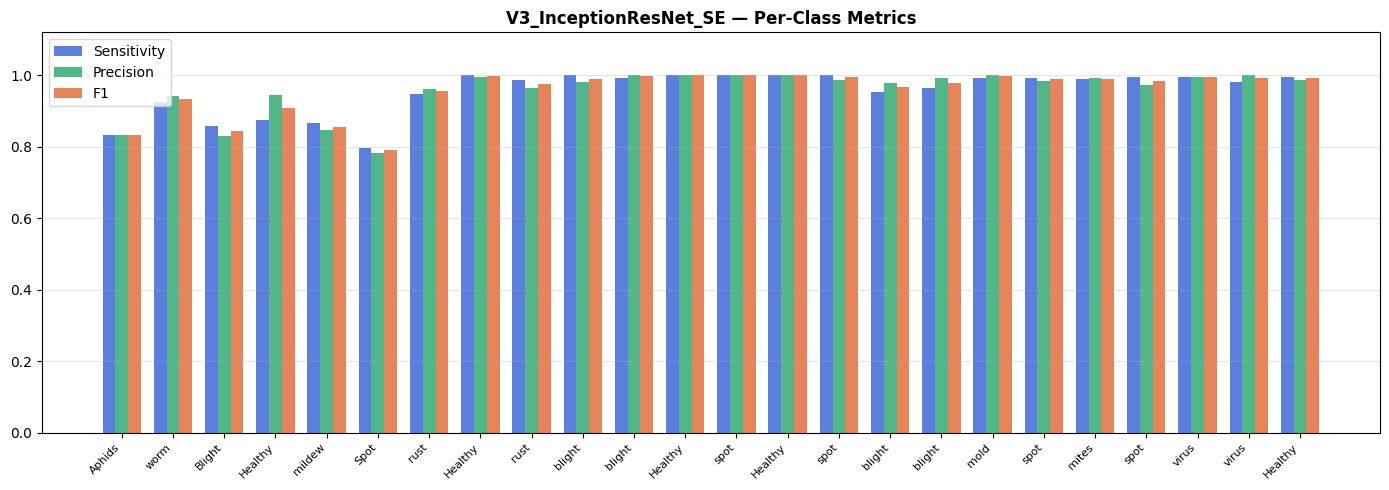

In [18]:
# ── Per-class metric bars ─────────────────────────────────────────────────
fig,ax=plt.subplots(figsize=(14,5))
x=np.arange(NUM_CLASSES); w=0.25
ax.bar(x-w,per_class_df['sensitivity'],w,label='Sensitivity',color='#5B7FDE')
ax.bar(x,  per_class_df['precision'],  w,label='Precision',  color='#52B788')
ax.bar(x+w,per_class_df['f1'],         w,label='F1',         color='#E8845A')
ax.set_xticks(x)
ax.set_xticklabels([c.split('_')[-1][:8] for c in TARGET_CLASSES],rotation=45,ha='right',fontsize=8)
ax.set_ylim(0,1.12); ax.legend(); ax.grid(True,axis='y',alpha=0.3)
ax.set_title(f'{NOTEBOOK_ID} — Per-Class Metrics',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'per_class_metrics.png'),dpi=120,bbox_inches='tight')
plt.show()


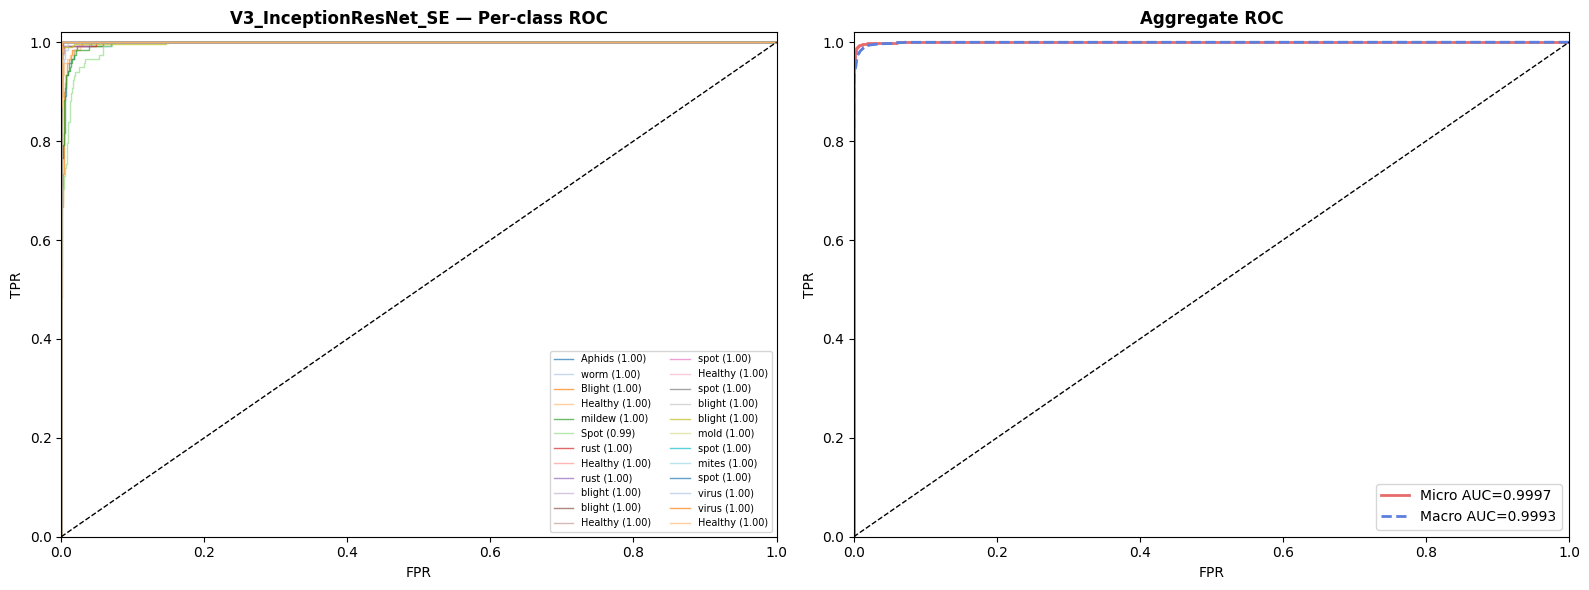

Micro AUC=0.9997  Macro AUC=0.9993


In [19]:
# ── ROC curves ────────────────────────────────────────────────────────────
y_bin=label_binarize(y_true,classes=list(range(NUM_CLASSES)))
fpr_d,tpr_d,auc_d={},{},{}
for i in range(NUM_CLASSES):
    fpr_d[i],tpr_d[i],_=roc_curve(y_bin[:,i],y_prob[:,i]); auc_d[i]=auc(fpr_d[i],tpr_d[i])
fpr_d['micro'],tpr_d['micro'],_=roc_curve(y_bin.ravel(),y_prob.ravel())
auc_d['micro']=auc(fpr_d['micro'],tpr_d['micro'])
all_fpr=np.unique(np.concatenate([fpr_d[i] for i in range(NUM_CLASSES)]))
mean_tpr=np.zeros_like(all_fpr)
for i in range(NUM_CLASSES): mean_tpr+=np.interp(all_fpr,fpr_d[i],tpr_d[i])
mean_tpr/=NUM_CLASSES
fpr_d['macro'],tpr_d['macro']=all_fpr,mean_tpr; auc_d['macro']=auc(all_fpr,mean_tpr)

fig,axes=plt.subplots(1,2,figsize=(16,6))
for i,color in zip(range(NUM_CLASSES),cycle(plt.cm.tab20.colors)):
    axes[0].plot(fpr_d[i],tpr_d[i],color=color,lw=1,alpha=0.7,
                 label=f'{TARGET_CLASSES[i].split("_")[-1]} ({auc_d[i]:.2f})')
axes[0].plot([0,1],[0,1],'k--',lw=1); axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title(f'{NOTEBOOK_ID} — Per-class ROC',fontweight='bold')
axes[0].legend(loc='lower right',fontsize=7,ncol=2)
axes[1].plot(fpr_d['micro'],tpr_d['micro'],'#E86B6B',lw=2,label=f'Micro AUC={auc_d["micro"]:.4f}')
axes[1].plot(fpr_d['macro'],tpr_d['macro'],'#5B7FDE',lw=2,ls='--',label=f'Macro AUC={auc_d["macro"]:.4f}')
axes[1].plot([0,1],[0,1],'k--',lw=1); axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Aggregate ROC',fontweight='bold'); axes[1].legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'roc_curves.png'),dpi=120,bbox_inches='tight'); plt.show()

np.save(os.path.join(LOG_DIR,'y_prob.npy'),y_prob)
np.save(os.path.join(LOG_DIR,'y_true.npy'),y_true)
roc_df=pd.DataFrame({
    'class':list(range(NUM_CLASSES))+['micro','macro'],
    'class_name':TARGET_CLASSES+['micro_avg','macro_avg'],
    'auc':[auc_d[i] for i in range(NUM_CLASSES)]+[auc_d['micro'],auc_d['macro']]
})
roc_df.to_csv(os.path.join(LOG_DIR,'roc_auc.csv'),index=False)
print(f'Micro AUC={auc_d["micro"]:.4f}  Macro AUC={auc_d["macro"]:.4f}')


In [20]:
# ── Save model ────────────────────────────────────────────────────────────
model.save(os.path.join(BASE_DIR,'model.h5'))
with open(os.path.join(BASE_DIR,'class_mapping.json'),'w') as f:
    json.dump({'idx_to_class':IDX_TO_CLASS,'class_to_idx':CLASS_TO_IDX,
               'notebook':NOTEBOOK_ID},f,indent=2)
print(f'FINAL SUMMARY — {NOTEBOOK_ID}')
print(f'  Accuracy  : {acc:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  Macro AUC : {auc_d["macro"]:.4f}')
print(f'  Params    : {model.count_params():,}')
print(f'\nAll logs saved to: {LOG_DIR}')


FINAL SUMMARY — V3_InceptionResNet_SE
  Accuracy  : 0.9673
  F1-Score  : 0.9674
  Macro AUC : 0.9993
  Params    : 1,606,652

All logs saved to: /root/plant_project/V3_InceptionResNet_SE/logs


In [21]:
import shutil, os

src = '/root/plant_project'
dst = '/kaggle/working/plant_project'

if os.path.exists(dst):
    shutil.rmtree(dst)          # copytree requires dst to not already exist

shutil.copytree(src, dst)
print("Directory copied to /kaggle/working/ — now visible in Output tab")


shutil.make_archive('/kaggle/working/plant_project/V3_InceptionResNet_SE/logs', 'zip', '/kaggle/working/plant_project/V3_InceptionResNet_SE/logs')
print("Zipped!")

Directory copied to /kaggle/working/ — now visible in Output tab
Zipped!
